In [1]:
import pandas as pd
import matplotlib.pyplot as plt

tickets = pd.read_csv("tickets.csv")
teams = pd.read_csv("teams.csv")

In [2]:
tickets.head()

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5


In [3]:
teams.head()

,team_id,team,department
0,T1,AccountCare,Service
1,T2,BillingHelp,Service
2,T3,AppSupport,Technical
3,T4,DeviceHelp,Technical


In [4]:
tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         13 non-null     int64 
 1   month             13 non-null     object
 2   team_id           13 non-null     object
 3   channel           13 non-null     object
 4   resolution_hours  13 non-null     int64 
 5   satisfaction      13 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 756.0+ bytes


In [5]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   team_id     4 non-null      object
 1   team        4 non-null      object
 2   department  4 non-null      object
dtypes: object(3)
memory usage: 228.0+ bytes


In [6]:
tickets.describe()

,ticket_id,resolution_hours,satisfaction
count,13.000000,13.000000,13.000000
mean,6.923077,23.846154,3.692308
std,3.774068,9.290193,1.031553
min,1.000000,8.000000,2.000000
25%,4.000000,18.000000,3.000000
50%,7.000000,24.000000,4.000000
75%,10.000000,30.000000,4.000000
max,12.000000,40.000000,5.000000


In [7]:
teams.describe()

,team_id,team,department
count,4,4,4
unique,4,4,2
top,T1,AccountCare,Service
freq,1,1,2


## P1

In [8]:
# Confirm numeric data types
tickets["resolution_hours"] = pd.to_numeric(tickets["resolution_hours"])
tickets["satisfaction"] = pd.to_numeric(tickets["satisfaction"])

print("Data types:")
print(tickets[["resolution_hours", "satisfaction"]].dtypes)

Data types:
resolution_hours    int64
satisfaction        int64
dtype: object


In [9]:
# Remove exact duplicate row
tickets = tickets.drop_duplicates()

# Merge tickets with teams using left join
merged = tickets.merge(
    teams,
    on="team_id",
    how="left"
)

In [10]:
# Check that merged DataFrame has exactly 12 rows
assert len(merged) == 12

# Check that no team_id is unmatched
assert merged["department"].isna().sum() == 0

print("\nMerged Data:")
print(merged)


Merged Data:
    ticket_id month team_id channel  resolution_hours  satisfaction  \
0           1   Jan      T1   Email                12             4   
1           2   Jan      T2    Chat                28             3   
2           3   Jan      T3   Phone                36             2   
3           4   Jan      T4   Email                20             4   
4           5   Feb      T1    Chat                 8             5   
5           6   Feb      T2   Phone                30             3   
6           7   Feb      T3   Email                18             4   
7           8   Feb      T4    Chat                40             2   
8           9   Mar      T1   Phone                16             4   
9          10   Mar      T2   Email                22             4   
10         11   Mar      T3    Chat                32             3   
11         12   Mar      T4   Phone                24             5   

           team department  
0   AccountCare    Service  
1   

## P2

In [11]:
# Create breach_flag
merged["breach_flag"] = (
    merged["resolution_hours"] > 24
).astype(int)

print("\nData with breach_flag:")
print(merged)


Data with breach_flag:
    ticket_id month team_id channel  resolution_hours  satisfaction  \
0           1   Jan      T1   Email                12             4   
1           2   Jan      T2    Chat                28             3   
2           3   Jan      T3   Phone                36             2   
3           4   Jan      T4   Email                20             4   
4           5   Feb      T1    Chat                 8             5   
5           6   Feb      T2   Phone                30             3   
6           7   Feb      T3   Email                18             4   
7           8   Feb      T4    Chat                40             2   
8           9   Mar      T1   Phone                16             4   
9          10   Mar      T2   Email                22             4   
10         11   Mar      T3    Chat                32             3   
11         12   Mar      T4   Phone                24             5   

           team department  breach_flag  
0   Accoun

In [12]:
# Department summary
department_summary = merged.groupby("department").agg(
    total_tickets=("ticket_id", "count"),
    breached_count=("breach_flag", "sum")
).reset_index()

# Calculate SLA breach rate
department_summary["sla_breach_rate_percent"] = (
    department_summary["breached_count"]
    / department_summary["total_tickets"]
    * 100
)

print("\nDepartment Summary:")
print(department_summary)


Department Summary:
  department  total_tickets  breached_count  sla_breach_rate_percent
0    Service              6               2                33.333333
1  Technical              6               3                50.000000


In [13]:
# Team summary
team_summary = merged.groupby(["team_id", "team"]).agg(
    total_tickets=("ticket_id", "count"),
    breached_count=("breach_flag", "sum")
).reset_index()

# Calculate team breach rate
team_summary["breach_rate_percent"] = (
    team_summary["breached_count"]
    / team_summary["total_tickets"]
    * 100
)

# Find team with highest breach rate
highest_breach_team = team_summary.loc[
    team_summary["breach_rate_percent"].idxmax()
]

print("\nTeam Summary:")
print(team_summary)

print("\nTeam with Highest Breach Rate:")
print("Team:", highest_breach_team["team"])
print("Breached Count:", highest_breach_team["breached_count"])
print("Total Tickets:", highest_breach_team["total_tickets"])
print("Breach Rate:", highest_breach_team["breach_rate_percent"], "%")


Team Summary:
  team_id         team  total_tickets  breached_count  breach_rate_percent
0      T1  AccountCare              3               0             0.000000
1      T2  BillingHelp              3               2            66.666667
2      T3   AppSupport              3               2            66.666667
3      T4   DeviceHelp              3               1            33.333333

Team with Highest Breach Rate:
Team: BillingHelp
Breached Count: 2
Total Tickets: 3
Breach Rate: 66.66666666666666 %


## P3

In [14]:
# Monthly average resolution hours
month_order = ["Jan", "Feb", "Mar"]

monthly_summary = (
    merged.groupby("month")["resolution_hours"]
    .mean()
    .reindex(month_order)
)

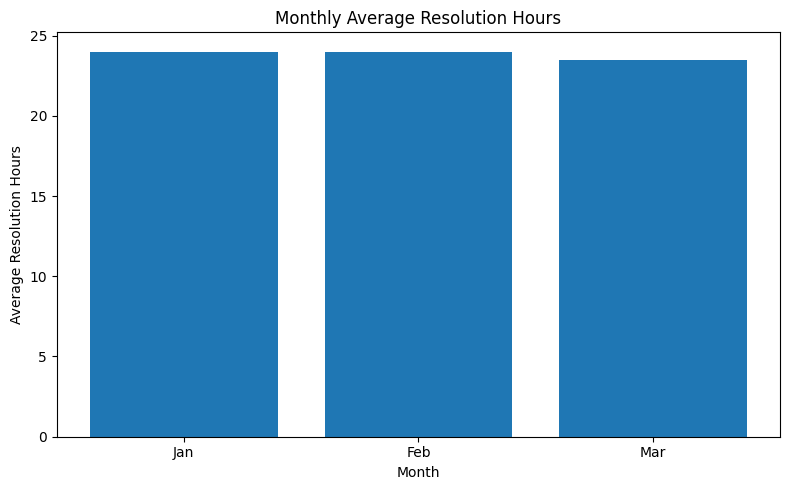

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(monthly_summary.index,monthly_summary.values)

plt.title("Monthly Average Resolution Hours")
plt.xlabel("Month")
plt.ylabel("Average Resolution Hours")

plt.tight_layout()

In [20]:
# Export clean merged DataFrame
merged.to_csv("clean_data.csv",index=False)

# Export department summary
department_summary.to_csv("python_summary.csv",index=False)

print("\nFiles exported successfully:")
print("outputs/python_chart.png")
print("outputs/clean_data.csv")
print("outputs/python_summary.csv")


Files exported successfully:
outputs/python_chart.png
outputs/clean_data.csv
outputs/python_summary.csv
